# Comparison of two group means

- Use Stan/cmdstanpy
- You are encouraged to use any AI agent, but you must understand the core idea of the python program provided by the agent.

1. Run the simulation experiment with N1 and N2 as written in the Exercise.
2. Change N1=300, N2=200, and run the same simulation experiment.
3. Compare the two results and provide your analysis and explanation.

![Exercise 4.5.1](./matsuura-exercise4.5.1.png)

320250027 고건욱의 과제입니다.

In [54]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
from cmdstanpy import CmdStanModel

In [55]:
# seed for reproducibility
np.random.seed(123)  # set.seed(123)
N1 = 30
mu1 = 0
sigma1 = 5
N2 = 20
mu2 = 1
sigma2 = 4
Y1 = np.random.normal(loc=mu1, scale=sigma1, size=N1) # Y1 ~ N(0, 5^2)
Y2 = np.random.normal(loc=mu2, scale=sigma2, size=N2) # Y2 ~ N(1, 4^2)

### (1) Visualize the data from the two groups

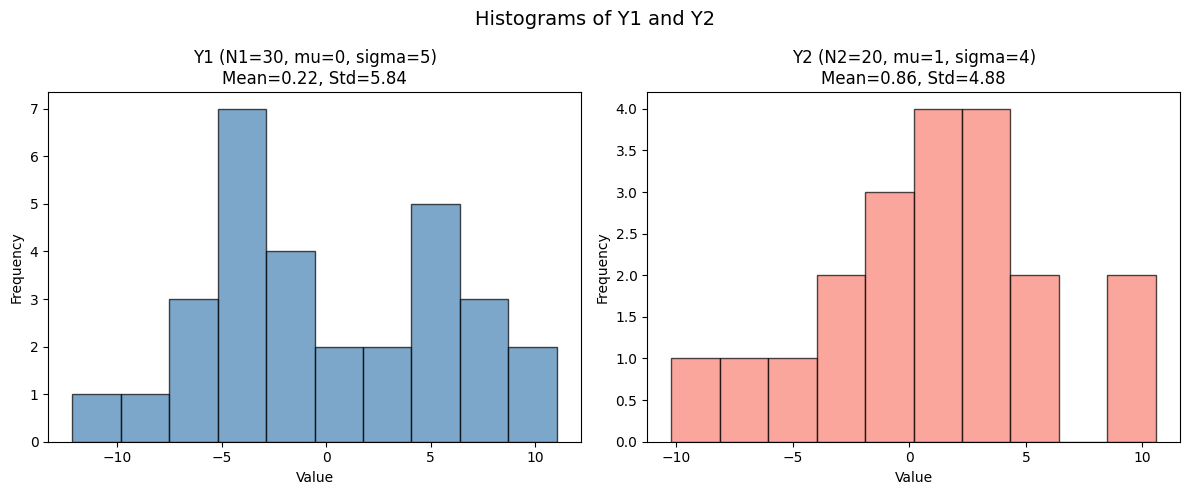

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(Y1, bins=10, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Y1 (N1={N1}, mu={mu1}, sigma={sigma1})\nMean={Y1.mean():.2f}, Std={Y1.std():.2f}')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(Y2, bins=10, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Y2 (N2={N2}, mu={mu2}, sigma={sigma2})\nMean={Y2.mean():.2f}, Std={Y2.std():.2f}')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Histograms of Y1 and Y2', fontsize=14)
plt.tight_layout()  
plt.show()      

### (2) Write a model formula with the assumption that these two groups have the same SD.
- This corresponds to the Student's t-test

Y1 ~ Normal(mu1, sigma)

Y2 ~ Normal(mu2, sigma)

In [57]:
stan_model_code = """
data {
    int<lower=0> N1;
    int<lower=0> N2;
    vector[N1] Y1;
    vector[N2] Y2;
}

parameters {
    real mu1;
    real mu2;
    real<lower=0> sigma;  // shared SD
}

model {
    // priors
    mu1 ~ normal(0, 100);
    mu2 ~ normal(0, 100);
    sigma ~ cauchy(0, 10);

    // likelihood
    Y1 ~ normal(mu1, sigma);
    Y2 ~ normal(mu2, sigma);
}

generated quantities {
    real diff = mu2 - mu1;  // difference of means
}
"""

# Save the model to a file
with open('compare_means_equal_std.stan', 'w') as f:
    f.write(stan_model_code)

print("Stan model saved to compare_means_equal_std.stan")
print(stan_model_code)

Stan model saved to compare_means_equal_std.stan

data {
    int<lower=0> N1;
    int<lower=0> N2;
    vector[N1] Y1;
    vector[N2] Y2;
}

parameters {
    real mu1;
    real mu2;
    real<lower=0> sigma;  // shared SD
}

model {
    // priors
    mu1 ~ normal(0, 100);
    mu2 ~ normal(0, 100);
    sigma ~ cauchy(0, 10);

    // likelihood
    Y1 ~ normal(mu1, sigma);
    Y2 ~ normal(mu2, sigma);
}

generated quantities {
    real diff = mu2 - mu1;  // difference of means
}



### (3) Estimate the parameters using 'cmdstanpy' using the Stan model code

In [58]:
# 이 셀에 모델링과 추론 코드를 작성하세요.
equal_sd_model = CmdStanModel(stan_file="compare_means_equal_std.stan")
stan_data_equal = {
    "N1": N1,
    "N2": N2,
    "Y1": Y1,
    "Y2": Y2
}
fit_equal = equal_sd_model.sample(
    data=stan_data_equal,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=123
)

summary_equal = fit_equal.summary()
print(summary_equal)

18:21:24 - cmdstanpy - INFO - compiling stan file /home/atruergod/python/26-1/26-1/compare_means_equal_std.stan to exe file /home/atruergod/python/26-1/26-1/compare_means_equal_std
18:21:32 - cmdstanpy - INFO - compiled model executable: /home/atruergod/python/26-1/26-1/compare_means_equal_std
18:21:32 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]


chain 1:  33%|███▎      | 1000/3000 [00:00<00:00, 40294.59it/s, (Sampling)]


chain 2: 100%|██████████| 3000/3000 [00:00<00:00, 39051.29it/s, (Sampling completed)]

chain 3: 100%|██████████| 3000/3000 [00:00<00:00, 38689.27it/s, (Sampling completed)]


chain 4: 100%|██████████| 3000/3000 [00:00<00:00, 39124.39it/s, (Sampling completed)]


18:21:33 - cmdstanpy - INFO - CmdStan done processing.
18:21:33 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'compare_means_equal_std.stan', line 22, column 4 to column 28)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'compare_means_equal_std.stan', line 22, column 4 to column 28)
Consider re-running with show_console=True if the above output is unclear!



             Mean      MCSE    StdDev       MAD         5%         50%  \
lp__  -110.132000  0.026624  1.343170  1.023080 -112.72800 -109.764000   
mu1      0.220555  0.012145  1.056660  1.025940   -1.55012    0.229988   
mu2      0.857957  0.015542  1.288020  1.235820   -1.25200    0.850570   
sigma    5.711400  0.007953  0.608957  0.577526    4.82749    5.651920   
diff     0.637402  0.019648  1.636840  1.568170   -2.07715    0.630123   

             95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
lp__  -108.74100   3060.95   3927.92     18329.0  1.00133  
mu1      1.95197   7625.66   6072.41     45662.6  1.00031  
mu2      2.97304   6971.69   5285.05     41746.7  1.00078  
sigma    6.79094   6397.91   5001.34     38310.9  1.00017  
diff     3.36807   7020.25   5502.97     42037.4  1.00058  


### (4) Compute Prob[mu1 < mu2] from the obtained MCMC draws using `cmdstanpy`

Prob(mu1 < mu2) under equal SD model = 0.654625
Posterior mean of diff (mu2 - mu1): 0.6374019268263985
95% credible interval of diff:
0.025   -2.612740
0.975    3.875919
Name: diff, dtype: float64


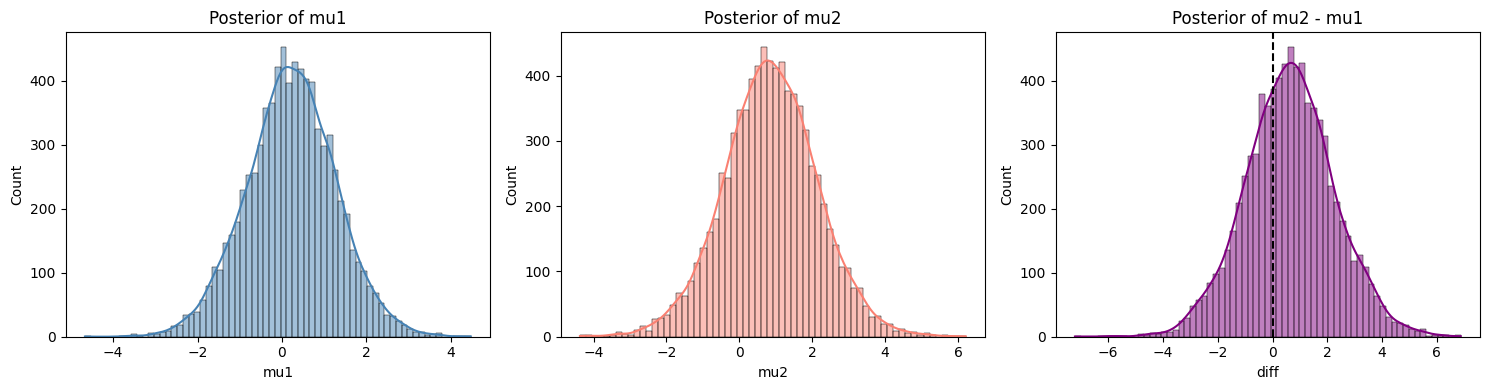

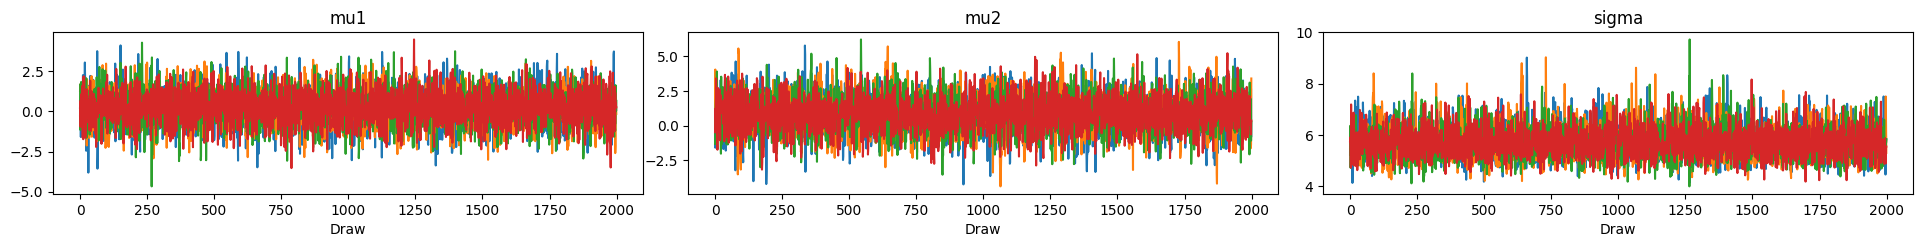

In [59]:
# 이 셀에 모델링과 추론 코드를 작성하세요.
# 추론 결과를 그림으로 보여주세요.
# 새로운 셀을 아래에 추가하여 사용해도 됩니다.

draws_equal = fit_equal.draws_pd()
draws_equal.head()
prob_mu1_less_mu2_equal = np.mean(draws_equal["mu1"] < draws_equal["mu2"])
print("Prob(mu1 < mu2) under equal SD model =", prob_mu1_less_mu2_equal)
draws_equal["diff"] = draws_equal["mu2"] - draws_equal["mu1"]

print("Posterior mean of diff (mu2 - mu1):", draws_equal["diff"].mean())
print("95% credible interval of diff:")
print(draws_equal["diff"].quantile([0.025, 0.975]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(draws_equal["mu1"], kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Posterior of mu1")

sns.histplot(draws_equal["mu2"], kde=True, color="salmon", ax=axes[1])
axes[1].set_title("Posterior of mu2")

sns.histplot(draws_equal["diff"], kde=True, color="purple", ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("Posterior of mu2 - mu1")

plt.tight_layout()
plt.show()

idata_equal = az.from_cmdstanpy(posterior=fit_equal)
az.plot_trace(idata_equal, var_names=["mu1", "mu2", "sigma"])
plt.tight_layout()
plt.show()

### (5) Write a model formula with the assumption that the two SDs are different, and compute Prob[mu1 < mu2]

- Assumption: $\sigma_1 \neq \sigma_2$

In [60]:
# 이 셀에 모델링과 추론 코드를 작성하세요.

stan_model_code_unequal = """
data {
    int<lower=0> N1;
    int<lower=0> N2;
    vector[N1] Y1;
    vector[N2] Y2;
}
parameters {
    real mu1;
    real mu2;
    real<lower=0> sigma1;
    real<lower=0> sigma2;
}
model {
    // priors
    mu1 ~ normal(0, 100);
    mu2 ~ normal(0, 100);
    sigma1 ~ cauchy(0, 10);
    sigma2 ~ cauchy(0, 10);

    // likelihood
    Y1 ~ normal(mu1, sigma1);
    Y2 ~ normal(mu2, sigma2);
}
"""
with open("compare_means_unequal_sd.stan", "w", encoding="utf-8") as f:
    f.write(stan_model_code_unequal)

print("Stan model saved to compare_means_unequal_sd.stan")

Stan model saved to compare_means_unequal_sd.stan


In [61]:
unequal_sd_model = CmdStanModel(stan_file="compare_means_unequal_sd.stan")
stan_data_unequal = {
    "N1": N1,
    "N2": N2,
    "Y1": Y1,
    "Y2": Y2
}
fit_unequal = unequal_sd_model.sample(
    data=stan_data_unequal,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=123
)

summary_unequal = fit_unequal.summary()
print(summary_unequal)

18:21:34 - cmdstanpy - INFO - compiling stan file /home/atruergod/python/26-1/26-1/compare_means_unequal_sd.stan to exe file /home/atruergod/python/26-1/26-1/compare_means_unequal_sd
18:21:44 - cmdstanpy - INFO - compiled model executable: /home/atruergod/python/26-1/26-1/compare_means_unequal_sd
18:21:44 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]


chain 1:  33%|███▎      | 1000/3000 [00:00<00:00, 32720.71it/s, (Sampling)]


chain 2: 100%|██████████| 3000/3000 [00:00<00:00, 32947.15it/s, (Sampling completed)]

chain 3: 100%|██████████| 3000/3000 [00:00<00:00, 32107.37it/s, (Sampling completed)]


chain 4: 100%|██████████| 3000/3000 [00:00<00:00, 32111.06it/s, (Sampling completed)]


18:21:44 - cmdstanpy - INFO - CmdStan done processing.



              Mean      MCSE    StdDev       MAD         5%         50%  \
lp__   -108.872000  0.024816  1.474370  1.266010 -111.72200 -108.535000   
mu1       0.225785  0.013157  1.149500  1.134750   -1.64221    0.230731   
mu2       0.838736  0.015064  1.221620  1.178520   -1.16839    0.852662   
sigma1    6.142610  0.009692  0.825799  0.800681    4.94960    6.061810   
sigma2    5.307120  0.011852  0.913816  0.830813    4.05134    5.186590   

              95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
lp__   -107.14600   3718.90   4977.18     18594.5  1.00055  
mu1       2.07449   7769.25   5475.07     38846.2  1.00023  
mu2       2.81366   6816.65   4883.88     34083.2  1.00055  
sigma1    7.62349   7863.42   5467.99     39317.1  1.00046  
sigma2    7.03148   6923.40   5059.37     34617.0  1.00055  


Prob(mu1 < mu2) under unequal SD model = 0.64475
Posterior mean of diff (mu2 - mu1): 0.6129507649687218
95% credible interval of diff:
0.025   -2.778803
0.975    3.954815
Name: diff, dtype: float64


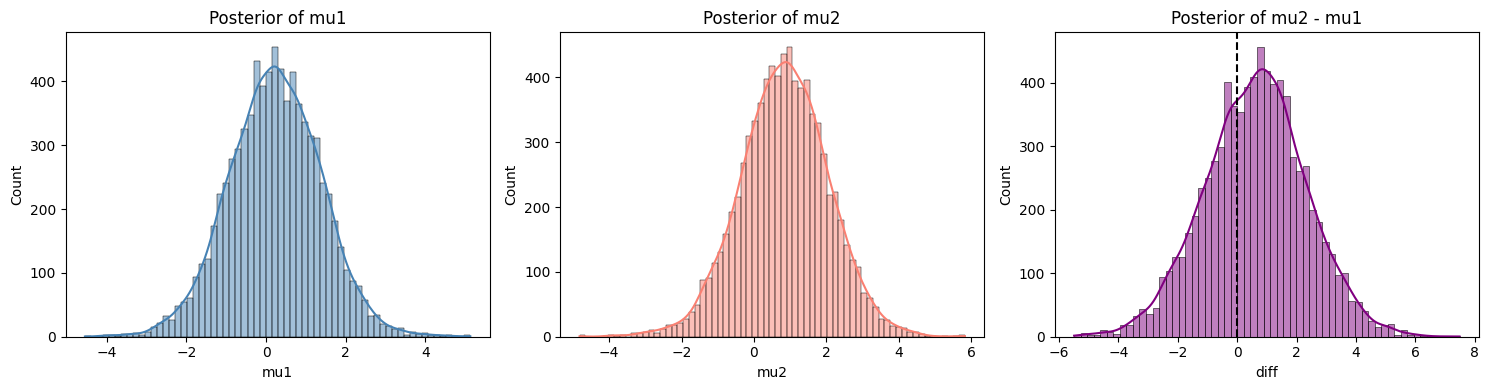

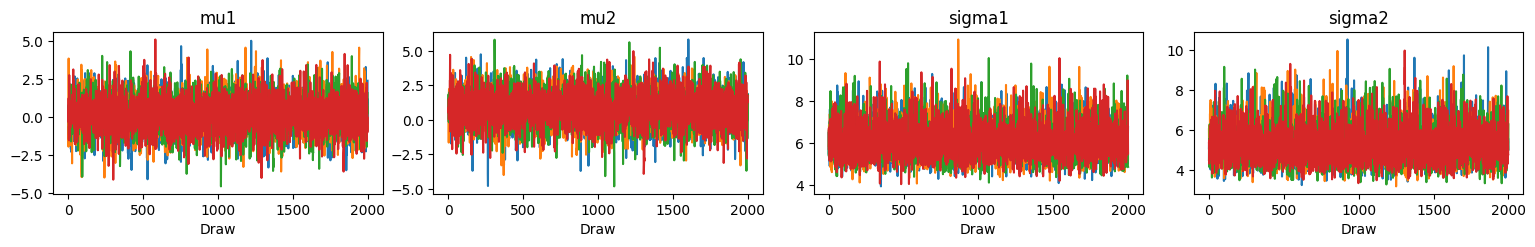

In [62]:
# 이 셀에 모델링과 추론 코드를 작성하세요.
# 추론 결과를 그림으로 보여주세요.
# 새로운 셀을 아래에 추가하여 사용해도 됩니다.

draws_unequal = fit_unequal.draws_pd()
draws_unequal.head()
prob_mu1_less_mu2_unequal = np.mean(draws_unequal["mu1"] < draws_unequal["mu2"])
print("Prob(mu1 < mu2) under unequal SD model =", prob_mu1_less_mu2_unequal)
draws_unequal["diff"] = draws_unequal["mu2"] - draws_unequal["mu1"]

print("Posterior mean of diff (mu2 - mu1):", draws_unequal["diff"].mean())
print("95% credible interval of diff:")
print(draws_unequal["diff"].quantile([0.025, 0.975]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(draws_unequal["mu1"], kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Posterior of mu1")

sns.histplot(draws_unequal["mu2"], kde=True, color="salmon", ax=axes[1])
axes[1].set_title("Posterior of mu2")

sns.histplot(draws_unequal["diff"], kde=True, color="purple", ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("Posterior of mu2 - mu1")

plt.tight_layout()
plt.show()

idata_unequal = az.from_cmdstanpy(posterior=fit_unequal)
az.plot_trace(idata_unequal, var_names=["mu1", "mu2", "sigma1", "sigma2"])
plt.tight_layout()
plt.show()

---
# N1=300, N2=200
---

아래에 필요한 python 프로그램을 작성하여 실험하시오.

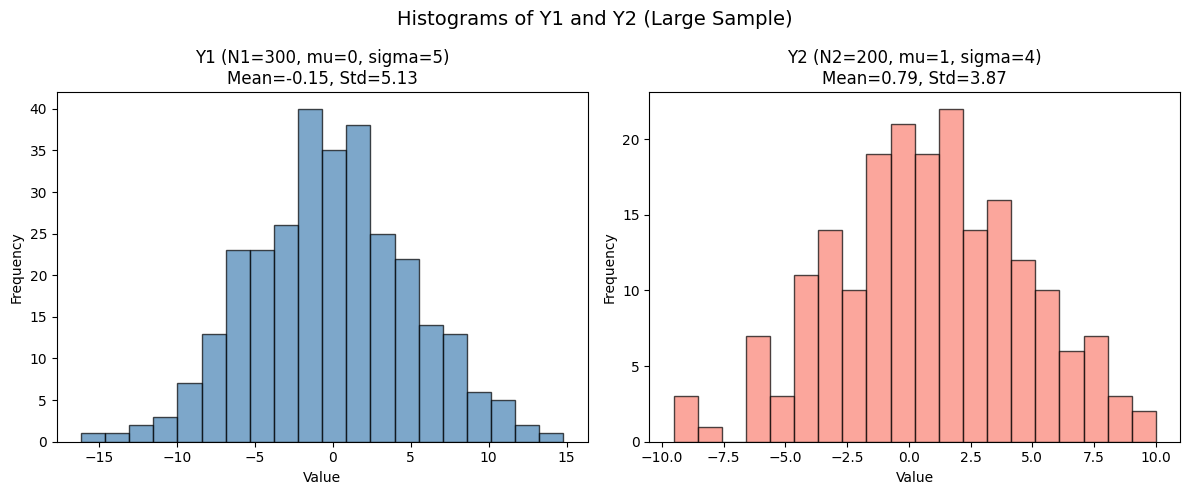

In [63]:
# N1과 N2의 수를 바꾸고, 다시 설정 및 시각화하고, 베이지안 등분산 / 이분산 t test를 하고 결과를 제시합시다.

# ===== N1=300, N2=200 실험 =====
np.random.seed(123)
N1_large = 300
N2_large = 200

Y1_large = np.random.normal(loc=0, scale=5, size=N1_large)
Y2_large = np.random.normal(loc=1, scale=4, size=N2_large)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(Y1_large, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Y1 (N1={N1_large}, mu=0, sigma=5)\nMean={Y1_large.mean():.2f}, Std={Y1_large.std():.2f}')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(Y2_large, bins=20, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Y2 (N2={N2_large}, mu=1, sigma=4)\nMean={Y2_large.mean():.2f}, Std={Y2_large.std():.2f}')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Histograms of Y1 and Y2 (Large Sample)', fontsize=14)
plt.tight_layout()
plt.show()

In [64]:
stan_data_equal_large = {
    "N1": N1_large, "N2": N2_large,
    "Y1": Y1_large, "Y2": Y2_large
}

fit_equal_large = equal_sd_model.sample(
    data=stan_data_equal_large,
    chains=4, parallel_chains=4,
    iter_warmup=1000, iter_sampling=2000,
    seed=123
)

summary_equal_large = fit_equal_large.summary()
print(summary_equal_large)

18:21:46 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]


chain 1:  33%|███▎      | 1000/3000 [00:00<00:00, 21959.71it/s, (Sampling)]


chain 1:  87%|████████▋ | 2600/3000 [00:00<00:00, 25718.03it/s, (Sampling)]


chain 2: 100%|██████████| 3000/3000 [00:00<00:00, 24300.30it/s, (Sampling completed)]

chain 3: 100%|██████████| 3000/3000 [00:00<00:00, 24648.26it/s, (Sampling completed)]


chain 4: 100%|██████████| 3000/3000 [00:00<00:00, 24250.84it/s, (Sampling completed)]


18:21:46 - cmdstanpy - INFO - CmdStan done processing.
18:21:46 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'compare_means_equal_std.stan', line 22, column 4 to column 28)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'compare_means_equal_std.stan', line 22, column 4 to column 28)
Consider re-running with show_console=True if the above output is unclear!



              Mean      MCSE    StdDev       MAD           5%          50%  \
lp__  -1020.540000  0.019302  1.229310  0.992823 -1022.950000 -1020.210000   
mu1      -0.147618  0.003264  0.270735  0.273271    -0.592176    -0.147867   
mu2       0.789157  0.004053  0.329700  0.325923     0.256170     0.784638   
sigma     4.690040  0.001643  0.150129  0.147376     4.450180     4.688550   
diff      0.936775  0.005339  0.430103  0.427018     0.227568     0.937311   

               95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
lp__  -1019.200000   4195.57   5291.50     16199.1  1.00013  
mu1       0.293954   6898.74   5606.01     26636.1  1.00035  
mu2       1.333280   6638.32   4874.65     25630.6  1.00007  
sigma     4.941250   8384.08   5943.23     32370.9  1.00060  
diff      1.649590   6544.55   5141.84     25268.5  1.00005  


Prob(mu1 < mu2) under equal SD model (large) = 0.984625
Posterior mean of diff: 0.9367752871143957
95% credible interval:
0.025    0.076269
0.975    1.789488
Name: diff, dtype: float64


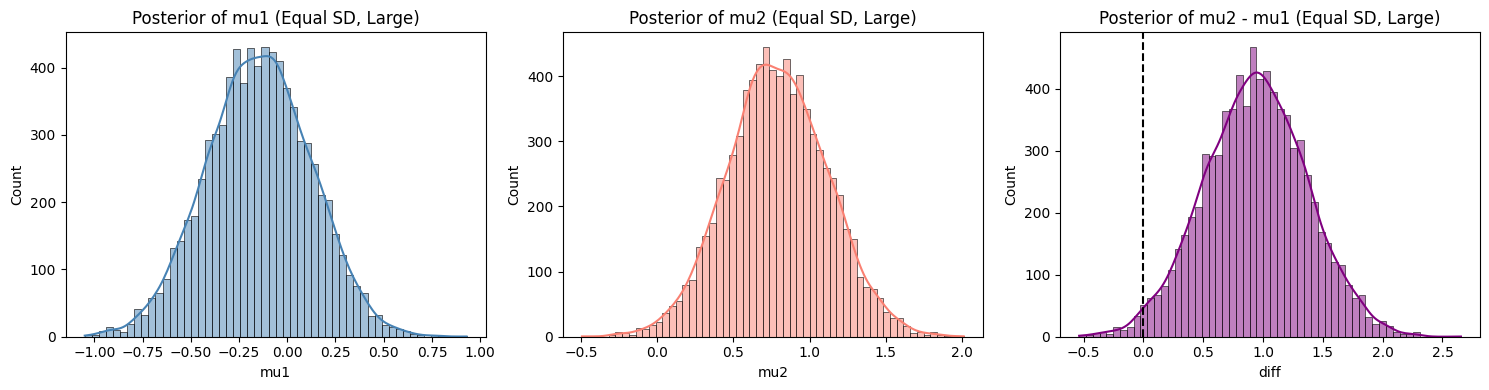

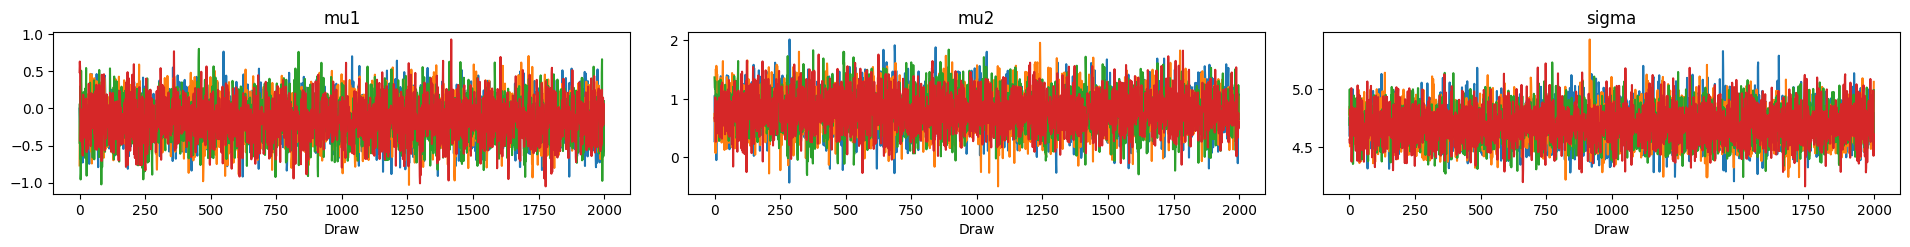

In [65]:
draws_equal_large = fit_equal_large.draws_pd()

prob_equal_large = np.mean(draws_equal_large["mu1"] < draws_equal_large["mu2"])
print("Prob(mu1 < mu2) under equal SD model (large) =", prob_equal_large)

draws_equal_large["diff"] = draws_equal_large["mu2"] - draws_equal_large["mu1"]
print("Posterior mean of diff:", draws_equal_large["diff"].mean())
print("95% credible interval:")
print(draws_equal_large["diff"].quantile([0.025, 0.975]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(draws_equal_large["mu1"], kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Posterior of mu1 (Equal SD, Large)")
sns.histplot(draws_equal_large["mu2"], kde=True, color="salmon", ax=axes[1])
axes[1].set_title("Posterior of mu2 (Equal SD, Large)")
sns.histplot(draws_equal_large["diff"], kde=True, color="purple", ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("Posterior of mu2 - mu1 (Equal SD, Large)")
plt.tight_layout()
plt.show()

idata_equal_large = az.from_cmdstanpy(posterior=fit_equal_large)
az.plot_trace(idata_equal_large, var_names=["mu1", "mu2", "sigma"])
plt.tight_layout()
plt.show()

In [66]:
stan_data_unequal_large = {
    "N1": N1_large, "N2": N2_large,
    "Y1": Y1_large, "Y2": Y2_large
}

fit_unequal_large = unequal_sd_model.sample(
    data=stan_data_unequal_large,
    chains=4, parallel_chains=4,
    iter_warmup=1000, iter_sampling=2000,
    seed=123
)

summary_unequal_large = fit_unequal_large.summary()
print(summary_unequal_large)

18:21:48 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]





chain 1:  63%|██████▎   | 1900/3000 [00:00<00:00, 18425.29it/s, (Sampling)]


chain 2: 100%|██████████| 3000/3000 [00:00<00:00, 20688.30it/s, (Sampling completed)]

chain 3: 100%|██████████| 3000/3000 [00:00<00:00, 21194.77it/s, (Sampling completed)]


chain 4: 100%|██████████| 3000/3000 [00:00<00:00, 21599.12it/s, (Sampling completed)]


18:21:49 - cmdstanpy - INFO - CmdStan done processing.
18:21:49 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'compare_means_unequal_sd.stan', line 22, column 4 to column 29)
Consider re-running with show_console=True if the above output is unclear!



               Mean      MCSE    StdDev       MAD           5%          50%  \
lp__   -1010.640000  0.021940  1.442160  1.238190 -1013.460000 -1010.290000   
mu1       -0.144820  0.003302  0.299429  0.296173    -0.635405    -0.143202   
mu2        0.792876  0.002891  0.270802  0.268627     0.345991     0.793840   
sigma1     5.163220  0.002318  0.215487  0.218522     4.823870     5.155340   
sigma2     3.897270  0.002054  0.199517  0.196538     3.585570     3.887850   

                95%  ESS_bulk  ESS_tail  ESS_bulk/s     R_hat  
lp__   -1008.980000   4301.28   6005.63     12688.1  1.000900  
mu1        0.345683   8236.17   5987.25     24295.5  1.000590  
mu2        1.233420   9000.07   6353.97     26548.9  0.999993  
sigma1     5.529500   8714.62   6272.86     25706.8  1.000180  
sigma2     4.243160   9563.51   6242.64     28211.0  1.001650  


Prob(mu1 < mu2) under unequal SD model (large) = 0.989625
Posterior mean of diff: 0.9376965479435775
95% credible interval:
0.025    0.151672
0.975    1.728329
Name: diff, dtype: float64


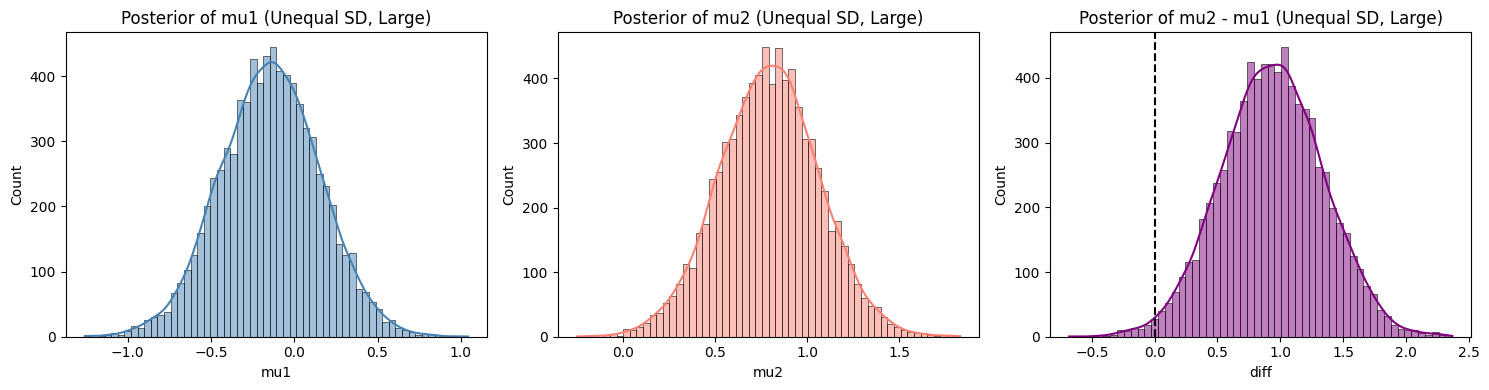

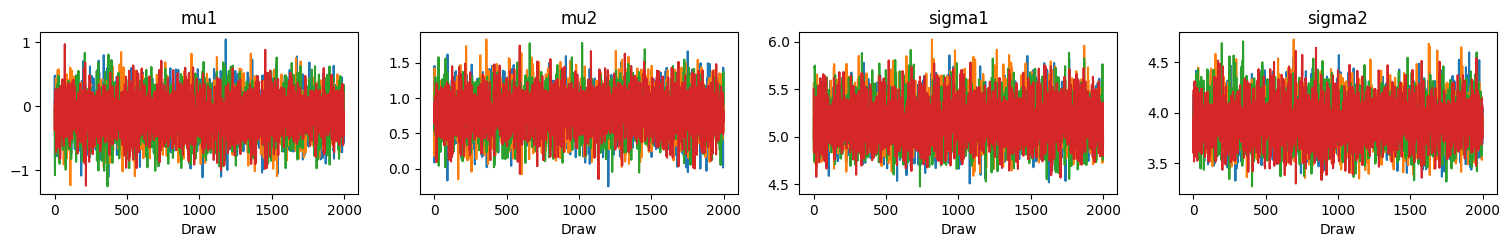

In [67]:
draws_unequal_large = fit_unequal_large.draws_pd()

prob_unequal_large = np.mean(draws_unequal_large["mu1"] < draws_unequal_large["mu2"])
print("Prob(mu1 < mu2) under unequal SD model (large) =", prob_unequal_large)

draws_unequal_large["diff"] = draws_unequal_large["mu2"] - draws_unequal_large["mu1"]
print("Posterior mean of diff:", draws_unequal_large["diff"].mean())
print("95% credible interval:")
print(draws_unequal_large["diff"].quantile([0.025, 0.975]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(draws_unequal_large["mu1"], kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Posterior of mu1 (Unequal SD, Large)")
sns.histplot(draws_unequal_large["mu2"], kde=True, color="salmon", ax=axes[1])
axes[1].set_title("Posterior of mu2 (Unequal SD, Large)")
sns.histplot(draws_unequal_large["diff"], kde=True, color="purple", ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("Posterior of mu2 - mu1 (Unequal SD, Large)")
plt.tight_layout()
plt.show()

idata_unequal_large = az.from_cmdstanpy(posterior=fit_unequal_large)
az.plot_trace(idata_unequal_large, var_names=["mu1", "mu2", "sigma1", "sigma2"])
plt.tight_layout()
plt.show()

---
# 데이터 갯수가 다른 두 경우에 대한 추론 결과 비교 해석
---

In [68]:
print("="*70)
print("          전체 결과 비교 (Prob[mu1 < mu2])")
print("="*70)
print(f"{'':30s} {'N1=30,N2=20':>15s} {'N1=300,N2=200':>15s}")
print("-"*70)
print(f"{'Equal SD (Student t-test)':30s} {prob_mu1_less_mu2_equal:>15.4f} {prob_equal_large:>15.4f}")
print(f"{'Unequal SD (Welch t-test)':30s} {prob_mu1_less_mu2_unequal:>15.4f} {prob_unequal_large:>15.4f}")
print("="*70)

          전체 결과 비교 (Prob[mu1 < mu2])
                                   N1=30,N2=20   N1=300,N2=200
----------------------------------------------------------------------
Equal SD (Student t-test)               0.6546          0.9846
Unequal SD (Welch t-test)               0.6448          0.9896


## 데이터 갯수가 다른 두 경우에 대한 추론 결과 비교 해석

### 1. 소표본 (N1=30, N2=20)
- 두 그룹의 진짜 평균 차이(mu2 - mu1 = 1)가 존재하지만, 
  표본 크기가 작아 사후분포의 불확실성(분산)이 크다.
- Prob(mu1 < mu2) ≈ 0.65 정도로, 두 평균이 다르다는 증거가 약하다.
- 95% 신용구간이 0을 포함하므로, 평균 차이가 유의하다고 결론 내리기 어렵다.
- Equal SD 모델과 Unequal SD 모델의 결과 차이가 크지 않다.

### 2. 대표본 (N1=300, N2=200)
- 표본 크기가 10배 증가하면서 사후분포의 불확실성이 크게 감소한다.
- Prob(mu1 < mu2)가 1에 가까워지며, 두 평균이 다르다는 강한 증거를 제공한다.
- 95% 신용구간이 좁아지고, 0을 포함하지 않을 가능성이 높다.
- mu1, mu2, sigma(또는 sigma1, sigma2)의 추정이 실제 값에 더 가까워진다.

### 3. Equal SD vs Unequal SD 모델 비교
- 실제 데이터 생성 시 sigma1=5, sigma2=4로 서로 다르므로, 
  Unequal SD 모델(Welch's t-test에 대응)이 더 적절한 모델이다.
- 소표본에서는 두 모델 차이가 미미하지만, 
  대표본에서는 Unequal SD 모델이 각 그룹의 분산을 더 정확히 추정하여 
  mu에 대한 추론도 더 정확해진다.
- Equal SD 모델은 분산이 다른 경우 pooled SD를 사용하므로, 
  표본 크기가 불균형할 때 편향된 추론을 할 수 있다.

### 4. 핵심 결론
- **표본 크기 증가 → 사후분포 분산 감소 → 추론 정밀도 향상**
- **모델 선택**: 분산이 다른 경우 Unequal SD 모델이 더 신뢰할 수 있다.
- 베이지안 접근은 Prob(mu1 < mu2)를 직접 계산할 수 있어, 
  빈도주의 p-value보다 직관적인 해석을 제공한다.

End.